# Démo (format rapport) — Autoencodeur débruiteur

> Objectif : illustrer le principe d’un **Denoising Autoencoder (DAE)** : on apprend une fonction $f_\theta$ qui reconstruit une image **propre** $x$ à partir d’une observation **bruitée** $\tilde{x}$.

Ce notebook est écrit comme un mini-rapport :

- **Partie A — MNIST (28×28)** : démo rapide, reproductible, entraînement court.
- **Partie B — Image locale** : on applique la même idée à l’image `../assets/inputs/image1.webp` (satellite) via un apprentissage sur *patchs*.

Sorties (pour la présentation Beamer) :
- `../assets/figures/demo_clean.png`
- `../assets/figures/demo_noisy.png`
- `../assets/figures/demo_denoised.png`

Remarque : la partie B peut **écraser** ces fichiers si vous exportez sur l’image locale (c’est voulu si vous voulez montrer votre image dans les slides).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models

# Reproductibilité (démo)
np.random.seed(0)
tf.random.set_seed(0)

# Dossiers (le notebook est dans notebooks-demo/ ; les figures vont dans assets/figures/)
FIG_DIR = os.path.normpath(os.path.join('..', 'assets', 'figures'))
INPUT_DIR = os.path.normpath(os.path.join('..', 'assets', 'inputs'))
os.makedirs(FIG_DIR, exist_ok=True)

# Paramètres globaux (démo + exports)
EXPORT_FOR_BEAMER = 'local'  # 'mnist' ou 'local'
PRINT_SHAPES = True

# Paramètres — MNIST
SIGMA_MNIST = 0.50
EPOCHS_MNIST = 3
BATCH_SIZE_MNIST = 256

# Paramètres — image locale
LOCAL_IMAGE_NAME = 'image1.webp'
MAX_SIDE = 320          # redimensionnement (rapide + stable)
SIGMA_LOCAL = 0.12      # bruit plus faible qu'en MNIST (image naturelle)
PATCH_SIZE = 64
N_PATCHES = 4000
EPOCHS_LOCAL = 6
BATCH_SIZE_LOCAL = 64

FIG_DIR, INPUT_DIR

c:\Users\alban\.conda\envs\tp_geo\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


('..\\assets\\figures', '..\\assets\\inputs')

## 1) Rappel théorique — Denoising Autoencoder (DAE)

Un **autoencodeur** est composé d’un encodeur $E_\theta$ et d’un décodeur $D_\theta$ :

$$z = E_\theta(x), \qquad \hat{x} = D_\theta(z).$$

Pour le **débruitage**, on définit un opérateur de corruption (modèle de bruit) $q(\tilde{x}\mid x)$, et on entraîne le réseau à prédire **l’image propre** à partir de **l’image bruitée** :

$$\min_\theta\; \mathbb{E}_{x\sim p_{data}}\;\mathbb{E}_{\tilde{x}\sim q(\cdot\mid x)}\;\ell\big(x,\; D_\theta(E_\theta(\tilde{x}))\big).$$

Dans ce notebook, on utilise :
- **Bruit gaussien additif** : $\tilde{x} = x + \sigma\varepsilon$, $\varepsilon\sim\mathcal{N}(0, I)$
- **Perte MSE** : $\ell(x,\hat{x}) = \|x-\hat{x}\|_2^2$ (moyennée sur les pixels)

On mesure l’amélioration via des métriques simples (MSE, PSNR) et surtout via l’inspection visuelle (avant/après).

In [2]:
def add_gaussian_noise(x, sigma):
    """Ajoute du bruit gaussien (float32) et clippe dans [0, 1]."""
    x = x.astype('float32')
    noisy = x + sigma * np.random.normal(0.0, 1.0, x.shape).astype('float32')
    return np.clip(noisy, 0.0, 1.0)

def mse(a, b):
    return float(np.mean((a.astype('float32') - b.astype('float32')) ** 2))

def psnr(a, b, max_i=1.0):
    m = mse(a, b)
    return 10.0 * np.log10((max_i ** 2) / (m + 1e-12))

def save_rgb(img01, filename):
    """Sauvegarde une image RGB dans [0,1] vers assets/figures/ (sans axes)."""
    path = os.path.join(FIG_DIR, filename)
    plt.figure(figsize=(4.6, 3.0))
    plt.imshow(np.clip(img01, 0.0, 1.0))
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig(path, dpi=220, bbox_inches='tight', pad_inches=0)
    plt.close()
    return path

def save_gray(img01, filename):
    """Sauvegarde une image grayscale (H,W) ou (H,W,1) dans [0,1]."""
    path = os.path.join(FIG_DIR, filename)
    plt.figure(figsize=(2.6, 2.6))
    plt.imshow(np.squeeze(np.clip(img01, 0.0, 1.0)), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig(path, dpi=220, bbox_inches='tight', pad_inches=0)
    plt.close()
    return path

'ok'

'ok'

## Partie A — MNIST (démo rapide et standard)

MNIST est un bon cas de demo rapide : les images sont petites, le réseau converge vite, et l’effet du bruit est facile à percevoir.

On suit exactement le protocole DAE :
- **Entrée (train)** : images bruitées $\tilde{x}$
- **Cible (train)** : images propres $x$
- **Perte** : MSE pixel-à-pixel

La section suivante construit les données bruitées, puis définit un petit AE convolutionnel.

In [3]:
# 1) Charger MNIST et normaliser
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype('float32') / 255.0)[..., None]
x_test = (x_test.astype('float32') / 255.0)[..., None]

if PRINT_SHAPES:
    print('x_train:', x_train.shape, x_train.dtype)
    print('x_test :', x_test.shape, x_test.dtype)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train: (60000, 28, 28, 1) float32
x_test : (10000, 28, 28, 1) float32


In [4]:
# 2) Ajouter du bruit gaussien
x_train_noisy = add_gaussian_noise(x_train, SIGMA_MNIST).astype('float32')
x_test_noisy = add_gaussian_noise(x_test, SIGMA_MNIST).astype('float32')

if PRINT_SHAPES:
    print('x_train_noisy:', x_train_noisy.shape)
    print('x_test_noisy :', x_test_noisy.shape)

x_train_noisy: (60000, 28, 28, 1)
x_test_noisy : (10000, 28, 28, 1)


### A2) Modèle de bruit et génération de $\tilde{x}$

On simule un bruit additif gaussien : $\tilde{x} = x + \sigma\varepsilon$ avec $\varepsilon\sim\mathcal{N}(0, I)$. Concrètement, on ajoute un bruit i.i.d. à chaque pixel, puis on **clippe** pour rester dans $[0,1]$ (valeurs d’intensité).

Le paramètre `SIGMA_MNIST` contrôle la sévérité du bruit : plus il est grand, plus l’image est dégradée. (Le code ci-dessus a déjà généré `x_train_noisy` et `x_test_noisy`.)

In [5]:
def build_denoising_ae():
    inp = layers.Input(shape=(28, 28, 1))

    # Encodeur
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Bottleneck
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)

    # Décodeur
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    out = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    model = models.Model(inp, out, name='denoising_ae')
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

model = build_denoising_ae()
model.summary()

Model: "denoising_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,201 (47.66 KB)

 Trainable params: 12,201 (47.66 KB)

 Non-trainable params: 0 (0.00 B)

### A3) Architecture : AE convolutionnel (encodeur / décodeur)

Pour des images, les couches convolutionnelles exploitent la **structure spatiale** (voisinage de pixels).

L’AE est composé de :
- un **encodeur** qui compresse progressivement l’image (réduction de résolution et augmentation de canaux) ;
- un **décodeur** qui reconstruit une image de même taille que l’entrée.

On termine par une activation `sigmoid` pour garantir une sortie dans $[0,1]$ (cohérente avec la normalisation).

In [12]:
history = model.fit(
    x_train_noisy, x_train,
    epochs=EPOCHS_MNIST,
    batch_size=BATCH_SIZE_MNIST,
    shuffle=True,
    validation_split=0.1,
    verbose=1,
 )

Epoch 1/3
211/211 ━━━━━━━━━━━━━━━━━━━━ 32s 132ms/step - loss: 0.1151 - val_loss: 0.1114
Epoch 2/3
211/211 ━━━━━━━━━━━━━━━━━━━━ 28s 134ms/step - loss: 0.1121 - val_loss: 0.1114
Epoch 3/3
211/211 ━━━━━━━━━━━━━━━━━━━━ 28s 132ms/step - loss: 0.1121 - val_loss: 0.1114


### A4) Entraînement : minimisation de $\|f_\theta(\tilde{x}) - x\|_2^2$

On entraîne le modèle en minimisant la MSE entre la sortie reconstruite et l’image propre. En pratique, on utilise un optimiseur (Adam) et on itère sur des mini-batchs.

Pour une démo, on garde peu d’époques. (Si vous voulez une meilleure qualité, augmentez `EPOCHS_MNIST`.)

Export MNIST -> ..\assets\figures\demo_mnist_noisy.png ..\assets\figures\demo_mnist_denoised.png ..\assets\figures\demo_mnist_clean.png


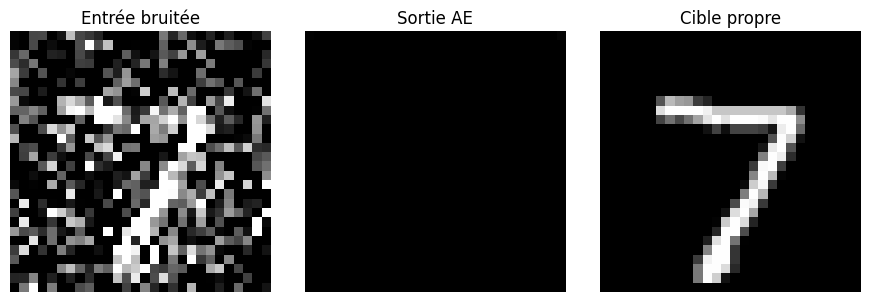

In [15]:
# 3) Prédiction sur un exemple test
idx = 0
x_clean = x_test[idx]          # (28, 28, 1)
x_noisy = x_test_noisy[idx]     # (28, 28, 1)
x_denoised = model.predict(x_noisy[None, ...], verbose=0)[0]

# Export MNIST (n'écrase pas les exports "local" de la Partie B)
p1 = save_gray(x_noisy, 'demo_mnist_noisy.png')
p2 = save_gray(x_denoised, 'demo_mnist_denoised.png')
p3 = save_gray(x_clean, 'demo_mnist_clean.png')
print('Export MNIST ->', p1, p2, p3)

# Affichage direct dans le notebook
fig, axs = plt.subplots(1, 3, figsize=(9.0, 3.0))
for ax, img, title in zip(
    axs,
    [x_noisy, x_denoised, x_clean],
    ['Entrée bruitée', 'Sortie AE', 'Cible propre'],
 ):
    ax.imshow(np.squeeze(np.clip(img, 0.0, 1.0)), cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

### A5) Résultats : visualisation + métriques

On compare :
- l’image **propre** $x$
- l’image **bruitée** $\tilde{x}$
- l’image **débruitée** $\hat{x}=f_\theta(\tilde{x})$

Pour un indicateur simple, on calcule aussi :
- **MSE** (plus petit = mieux)
- **PSNR** (plus grand = mieux)

In [14]:
print('MSE(noisy, clean)    =', mse(x_noisy, x_clean))
print('MSE(denoised, clean) =', mse(x_denoised, x_clean))
print('PSNR(noisy, clean)   =', psnr(x_noisy, x_clean))
print('PSNR(denoised, clean)=', psnr(x_denoised, x_clean))

MSE(noisy, clean)    = 0.11145501583814621
MSE(denoised, clean) = 0.07547105848789215
PSNR(noisy, clean)   = 9.529003820761066
PSNR(denoised, clean)= 11.222195589437899


## Partie B — Image locale (cas plus réaliste)

Dans la pratique, on ne dispose pas toujours d’un grand dataset étiqueté. On peut néanmoins entraîner un DAE à partir **d’une seule image** en procédant ainsi :

1. Charger une image propre $x$ (ici `assets/inputs/image1.webp`).
2. Générer une version bruitée $\tilde{x}$ (bruit gaussien).
3. Extraire des **patchs** aléatoires (petites fenêtres) pour créer beaucoup d’exemples d’entraînement.
4. Entraîner un petit AE convolutionnel sur la tâche $\tilde{p}\to p$ (patch bruité → patch propre).
5. Appliquer le réseau sur l’image entière (inférence convolutionnelle) pour obtenir $\hat{x}$.

Limites : le modèle apprend surtout la statistique de *cette* image ; ça marche mieux quand l’image est suffisamment grande et texturée, et pour des niveaux de bruit modérés.

### B1) Lecture et prétraitement de l’image

On charge l’image locale, on la convertit en RGB et on la ramène dans $[0,1]$.

Pour accélérer la démo, on redimensionne l’image (max côté = `MAX_SIDE`) puis on tronque les dimensions pour être multiples de 4 (compatibilité avec l’encodeur/décodeur à pooling/upsampling).

In [6]:
# Charger l'image locale (WEBP)
local_path = os.path.join(INPUT_DIR, LOCAL_IMAGE_NAME)
if not os.path.exists(local_path):
    raise FileNotFoundError(f"Image introuvable: {local_path}")

try:
    from PIL import Image
except ImportError as e:
    raise ImportError(
        "Pillow est requis pour lire les fichiers .webp. Installez-le avec: pip install pillow"
    ) from e

img = Image.open(local_path).convert('RGB')
w, h = img.size
scale = min(1.0, MAX_SIDE / max(w, h))
if scale < 1.0:
    img = img.resize((int(w * scale), int(h * scale)), resample=Image.BICUBIC)

x_local = (np.asarray(img).astype('float32') / 255.0)  # (H,W,3)
H, W, _ = x_local.shape
H2, W2 = (H // 4) * 4, (W // 4) * 4
x_local = x_local[:H2, :W2]
x_local_noisy = add_gaussian_noise(x_local, SIGMA_LOCAL)

print('Local clean:', x_local.shape, 'noisy:', x_local_noisy.shape)
print('Local baseline MSE  =', mse(x_local_noisy, x_local))
print('Local baseline PSNR =', psnr(x_local_noisy, x_local))

Local clean: (180, 320, 3) noisy: (180, 320, 3)
Local baseline MSE  = 0.012670454569160938
Local baseline PSNR = 18.972078039191487


### B2) Création d’un jeu d’entraînement à partir de patchs

Une seule image fournit peu d’exemples. L’idée est d’extraire aléatoirement beaucoup de **patchs** (sous-images) :
- Patch propre $p$ extrait de $x$
- Patch bruité $\tilde{p}$ extrait de $\tilde{x}$

On entraîne alors le réseau sur $(\tilde{p}, p)$ comme si c’était un dataset classique.

In [7]:
def sample_patches(clean_img, noisy_img, patch_size, n_patches):
    """Échantillonne des patchs alignés (noisy/clean) dans des images HxWxC."""
    h, w, c = clean_img.shape
    if h < patch_size or w < patch_size:
        raise ValueError(f"Image trop petite pour patch_size={patch_size}: {clean_img.shape}")
    xs = np.random.randint(0, h - patch_size + 1, size=n_patches)
    ys = np.random.randint(0, w - patch_size + 1, size=n_patches)
    clean_p = np.empty((n_patches, patch_size, patch_size, c), dtype='float32')
    noisy_p = np.empty((n_patches, patch_size, patch_size, c), dtype='float32')
    for i, (x0, y0) in enumerate(zip(xs, ys)):
        clean_p[i] = clean_img[x0:x0+patch_size, y0:y0+patch_size]
        noisy_p[i] = noisy_img[x0:x0+patch_size, y0:y0+patch_size]
    return noisy_p, clean_p

x_local_noisy_patches, x_local_clean_patches = sample_patches(
    x_local, x_local_noisy, PATCH_SIZE, N_PATCHES
 )

if PRINT_SHAPES:
    print('patches noisy:', x_local_noisy_patches.shape)
    print('patches clean:', x_local_clean_patches.shape)

patches noisy: (4000, 64, 64, 3)
patches clean: (4000, 64, 64, 3)


### B3) Modèle et entraînement (RGB)

On reprend une architecture encodeur/décodeur convolutionnelle. Le réseau est **totalement convolutionnel** : il peut s’appliquer à des patchs pendant l’entraînement, puis à l’image entière pendant l’inférence.

Comme en MNIST, la dernière couche est en `sigmoid` pour prédire une image dans $[0,1]$.

In [ ]:
def build_denoising_ae_rgb():
    """AE convolutionnel RGB (fully-convolutional).

    Remarque: l'entrée est (None, None, 3) pour permettre l'inférence
    sur l'image entière, tout en pouvant entraîner sur des patchs fixes.
    """
    inp = layers.Input(shape=(None, None, 3))

    # Encodeur
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Bottleneck
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)

    # Décodeur
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    out = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    m = models.Model(inp, out, name='denoising_ae_rgb')
    m.compile(optimizer='adam', loss='mean_squared_error')
    return m

model_local = build_denoising_ae_rgb()
model_local.summary()

history_local = model_local.fit(
    x_local_noisy_patches, x_local_clean_patches,
    epochs=EPOCHS_LOCAL,
    batch_size=BATCH_SIZE_LOCAL,
    shuffle=True,
    validation_split=0.1,
    verbose=1,
 )

Model: "denoising_ae_rgb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,579 (439.76 KB)

 Trainable params: 112,579 (439.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 36s 546ms/step - loss: 0.0174 - val_loss: 0.0075
Epoch 2/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 565ms/step - loss: 0.0065 - val_loss: 0.0059
Epoch 3/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 551ms/step - loss: 0.0055 - val_loss: 0.0052
Epoch 4/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 557ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 5/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 530ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 6/6
57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 518ms/step - loss: 0.0044 - val_loss: 0.0043


### B4) Inférence sur l’image entière et export

Une fois entraîné sur des patchs, le réseau peut être appliqué à l’image entière bruitée pour produire $\hat{x}$.

Si `EXPORT_FOR_BEAMER == 'local'`, on exporte les trois images `demo_clean.png`, `demo_noisy.png`, `demo_denoised.png` dans `assets/figures/` pour la présentation.

Local denoised MSE  = 0.004141363315284252
Local denoised PSNR = 23.82856667750207
Export LOCAL -> ..\assets\figures\demo_noisy.png ..\assets\figures\demo_denoised.png ..\assets\figures\demo_clean.png


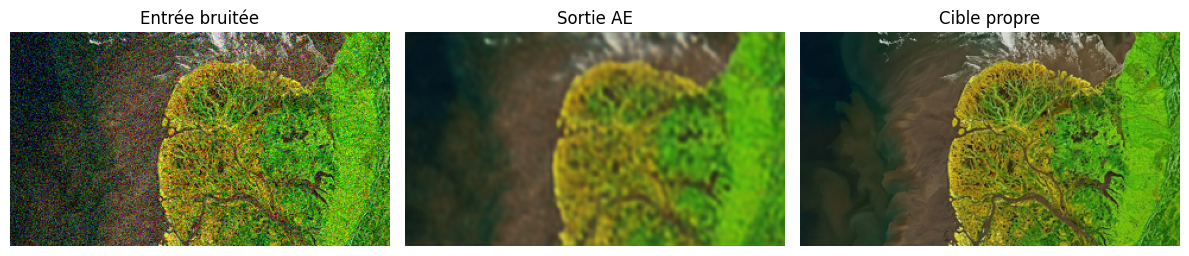

In [16]:
# Débruitage de l'image entière

def _build_denoising_ae_rgb_fully_conv():
    inp = layers.Input(shape=(None, None, 3))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    out = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
    m = models.Model(inp, out, name='denoising_ae_rgb_fully_conv')
    m.compile(optimizer='adam', loss='mean_squared_error')
    return m

# Si le modèle a une entrée fixée (patchs), on construit un modèle fully-conv
# équivalent et on transfère les poids.
model_for_inference = model_local
if tuple(model_local.input_shape[1:]) != tuple(x_local_noisy.shape):
    model_for_inference = _build_denoising_ae_rgb_fully_conv()
    model_for_inference.set_weights(model_local.get_weights())

x_local_denoised = model_for_inference.predict(x_local_noisy[None, ...], verbose=0)[0]
x_local_denoised = np.clip(x_local_denoised, 0.0, 1.0)

print('Local denoised MSE  =', mse(x_local_denoised, x_local))
print('Local denoised PSNR =', psnr(x_local_denoised, x_local))

if EXPORT_FOR_BEAMER == 'local':
    p1 = save_rgb(x_local_noisy, 'demo_noisy.png')
    p2 = save_rgb(x_local_denoised, 'demo_denoised.png')
    p3 = save_rgb(x_local, 'demo_clean.png')
    print('Export LOCAL ->', p1, p2, p3)
else:
    print("EXPORT_FOR_BEAMER != 'local' : pas d'export LOCAL")

# Affichage direct dans le notebook
fig, axs = plt.subplots(1, 3, figsize=(12.0, 4.0))
for ax, img, title in zip(
    axs,
    [x_local_noisy, x_local_denoised, x_local],
    ['Entrée bruitée', 'Sortie AE', 'Cible propre'],
 ):
    ax.imshow(np.clip(img, 0.0, 1.0))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()